In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

SEED = 42

np.random.seed(SEED)

PROJECT_DIR = Path(
    r"C:\Users\ADMIN\FinGraph-Sentinel"
)

DATA_DIR = PROJECT_DIR / "data"

RESULTS_DIR = DATA_DIR / "results"

PHASE14_DIR = RESULTS_DIR / "phase14"

PHASE15_DIR = RESULTS_DIR / "phase15"

PHASE15_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Phase 15 setup completed.")
print(f"Project directory: {PROJECT_DIR}")
print(f"Phase 15 output directory: {PHASE15_DIR}")

Phase 15 setup completed.
Project directory: C:\Users\ADMIN\FinGraph-Sentinel
Phase 15 output directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase15


In [2]:
# ==========================================
# PHASE 15 — CELL 2
# Load and inspect Phase 14 data
# ==========================================

import pandas as pd
import numpy as np

# Load Phase 14 validation data
validation_path = (
    PHASE14_DIR / "multi_signal_risk_validation.csv"
)

validation_df = pd.read_csv(validation_path)

print("Dataset loaded successfully.")
print(f"Shape: {validation_df.shape}")

print("\nColumns:")
print(validation_df.columns.tolist())

print("\nFirst 5 rows:")
display(validation_df.head())

print("\nData types:")
display(validation_df.dtypes)

print("\nMissing values:")
display(validation_df.isnull().sum())

Dataset loaded successfully.
Shape: (1180, 9)

Columns:
['date', 'degree', 'betweenness', 'pagerank', 'systemic_risk_score', 'multi_signal_risk_score', 'risk_percentile', 'exploratory_risk_category', 'future_stress_event']

First 5 rows:


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,exploratory_risk_category,future_stress_event
0,2021-11-12,0.585833,0.392917,0.795833,0.566667,0.585312,62.250000,Moderate,0
1,2021-11-12,0.585833,0.817917,0.809167,0.596667,0.702396,80.916667,High,0
2,2021-11-12,0.585833,0.817917,0.868333,0.605000,0.719271,82.416667,High,0
3,2021-11-12,0.109583,0.392917,0.070833,0.070833,0.161042,7.083333,Lower,0
4,2021-11-12,0.315000,0.392917,0.775417,0.342083,0.456354,39.875000,Lower,0



Data types:


date                             str
degree                       float64
betweenness                  float64
pagerank                     float64
systemic_risk_score          float64
multi_signal_risk_score      float64
risk_percentile              float64
exploratory_risk_category        str
future_stress_event            int64
dtype: object


Missing values:


date                         0
degree                       0
betweenness                  0
pagerank                     0
systemic_risk_score          0
multi_signal_risk_score      0
risk_percentile              0
exploratory_risk_category    0
future_stress_event          0
dtype: int64

In [3]:
# ==========================================
# PHASE 15 — CELL 3
# Yearly and regime distribution audit
# ==========================================

# Convert date column
validation_df["date"] = pd.to_datetime(
    validation_df["date"]
)

# Extract year
validation_df["year"] = (
    validation_df["date"].dt.year
)

print("Date range:")
print(validation_df["date"].min(), "to",
      validation_df["date"].max())

print("\nRows per year:")
display(
    validation_df["year"]
    .value_counts()
    .sort_index()
    .rename("row_count")
    .to_frame()
)

print("\nStress events per year:")
yearly_events = (
    validation_df
    .groupby("year")["future_stress_event"]
    .agg(
        total_rows="count",
        stress_events="sum",
        event_rate="mean"
    )
    .reset_index()
)

display(yearly_events)

print("\nRisk category distribution:")
display(
    validation_df["exploratory_risk_category"]
    .value_counts()
    .to_frame("row_count")
)

print("\nStress events by risk category:")
category_events = (
    validation_df
    .groupby("exploratory_risk_category")
    ["future_stress_event"]
    .agg(
        total_rows="count",
        stress_events="sum",
        event_rate="mean"
    )
    .reset_index()
)

display(category_events)

print("\nOverall stress event distribution:")
display(
    validation_df["future_stress_event"]
    .value_counts()
    .rename("count")
    .to_frame()
)

Date range:
2021-11-12 00:00:00 to 2026-07-16 00:00:00

Rows per year:


,row_count
year,
2021,40
2022,250
2023,250
2024,250
2025,250
2026,140



Stress events per year:


,year,total_rows,stress_events,event_rate
0,2021,40,10,0.25
1,2022,250,110,0.44
2,2023,250,0,0.00
3,2024,250,0,0.00
4,2025,250,40,0.16
5,2026,140,0,0.00



Risk category distribution:


,row_count
exploratory_risk_category,
Lower,587
Moderate,292
High,180
Very High,121



Stress events by risk category:


,exploratory_risk_category,total_rows,stress_events,event_rate
0,High,180,34,0.188889
1,Lower,587,50,0.085179
2,Moderate,292,47,0.160959
3,Very High,121,29,0.239669



Overall stress event distribution:


,count
future_stress_event,
0,1020
1,160


In [4]:
# ==========================================
# PHASE 15 — CELL 4
# Stress-event concentration by date
# ==========================================

date_analysis = (
    validation_df
    .groupby("date")["future_stress_event"]
    .agg(
        total_companies="count",
        stress_events="sum",
        event_rate="mean"
    )
    .reset_index()
)

# Keep dates containing at least one stress event
event_dates = date_analysis[
    date_analysis["stress_events"] > 0
].copy()

event_dates = event_dates.sort_values(
    "stress_events",
    ascending=False
)

print("Total unique dates:",
      validation_df["date"].nunique())

print("Dates containing stress events:",
      len(event_dates))

print("\nTop dates by stress-event count:")
display(event_dates.head(20))

print("\nStress events per event date:")
display(
    event_dates["stress_events"]
    .value_counts()
    .sort_index()
    .rename("number_of_dates")
    .to_frame()
)

print("\nDate-level event summary:")
print(
    f"Total event dates: {len(event_dates)}"
)

print(
    f"Maximum events on one date: "
    f"{event_dates['stress_events'].max()}"
)

Total unique dates: 118
Dates containing stress events: 16

Top dates by stress-event count:


,date,total_companies,stress_events,event_rate
3,2021-12-28,10,10,1.0
5,2022-01-26,10,10,1.0
6,2022-02-09,10,10,1.0
10,2022-04-07,10,10,1.0
11,2022-04-22,10,10,1.0
12,2022-05-06,10,10,1.0
13,2022-05-20,10,10,1.0
14,2022-06-06,10,10,1.0
19,2022-08-17,10,10,1.0
21,2022-09-15,10,10,1.0



Stress events per event date:


,number_of_dates
stress_events,
10,16



Date-level event summary:
Total event dates: 16
Maximum events on one date: 10


In [5]:
# ==========================================
# PHASE 15 — CELL 5
# Create date-level dataset
# ==========================================

date_level_df = (
    validation_df
    .groupby("date")
    .agg(
        degree=("degree", "mean"),
        betweenness=("betweenness", "mean"),
        pagerank=("pagerank", "mean"),
        systemic_risk_score=(
            "systemic_risk_score", "mean"
        ),
        multi_signal_risk_score=(
            "multi_signal_risk_score", "mean"
        ),
        risk_percentile=("risk_percentile", "mean"),
        total_companies=("future_stress_event", "count"),
        stress_events=("future_stress_event", "sum")
    )
    .reset_index()
)

# Create date-level binary target
date_level_df["date_stress_event"] = (
    date_level_df["stress_events"] > 0
).astype(int)

# Add year
date_level_df["year"] = (
    date_level_df["date"].dt.year
)

print("Date-level dataset shape:")
print(date_level_df.shape)

print("\nDate-level target distribution:")
display(
    date_level_df["date_stress_event"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("\nDate-level dataset preview:")
display(date_level_df.head())

print("\nDate-level events by year:")
display(
    date_level_df
    .groupby("year")["date_stress_event"]
    .agg(
        total_dates="count",
        stress_dates="sum"
    )
    .reset_index()
)

Date-level dataset shape:
(118, 11)

Date-level target distribution:


,count
date_stress_event,
0,102
1,16



Date-level dataset preview:


,date,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,total_companies,stress_events,date_stress_event,year
0,2021-11-12,0.377958,0.520417,0.545250,0.366333,0.452490,44.075000,10,0,0,2021
1,2021-11-29,0.393958,0.477917,0.541625,0.380458,0.448490,42.845833,10,0,0,2021
2,2021-12-13,0.393958,0.477917,0.536833,0.379167,0.446969,42.479167,10,0,0,2021
3,2021-12-28,0.396792,0.477917,0.561042,0.388125,0.455969,44.658333,10,10,1,2021
4,2022-01-11,0.396792,0.477917,0.561375,0.388042,0.456031,44.679167,10,0,0,2022



Date-level events by year:


,year,total_dates,stress_dates
0,2021,4,1
1,2022,25,11
2,2023,25,0
3,2024,25,0
4,2025,25,4
5,2026,14,0


In [6]:
# ==========================================
# PHASE 15 — CELL 6
# Date-level risk-score evaluation
# ==========================================

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

score_columns = [
    "degree",
    "betweenness",
    "pagerank",
    "systemic_risk_score",
    "multi_signal_risk_score",
    "risk_percentile"
]

target = date_level_df["date_stress_event"]

results = []

for score_column in score_columns:

    scores = date_level_df[score_column]

    # Original direction
    roc_original = roc_auc_score(target, scores)
    pr_original = average_precision_score(target, scores)

    # Reversed direction
    roc_reversed = roc_auc_score(target, -scores)
    pr_reversed = average_precision_score(target, -scores)

    if roc_original >= roc_reversed:
        best_direction = "normal"
        best_roc = roc_original
        best_pr = pr_original
    else:
        best_direction = "reversed"
        best_roc = roc_reversed
        best_pr = pr_reversed

    results.append({
        "signal": score_column,
        "roc_auc_original": roc_original,
        "roc_auc_reversed": roc_reversed,
        "best_direction": best_direction,
        "best_roc_auc": best_roc,
        "best_pr_auc": best_pr
    })

date_level_results = pd.DataFrame(results)

date_level_results = date_level_results.sort_values(
    "best_roc_auc",
    ascending=False
)

display(date_level_results)

# Save results
date_level_results.to_csv(
    PHASE15_DIR / "date_level_signal_evaluation.csv",
    index=False
)

print(
    "\nSaved: date_level_signal_evaluation.csv"
)

,signal,roc_auc_original,roc_auc_reversed,best_direction,best_roc_auc,best_pr_auc
4,multi_signal_risk_score,0.765319,0.234681,normal,0.765319,0.306346
0,degree,0.762255,0.237745,normal,0.762255,0.271119
5,risk_percentile,0.761642,0.238358,normal,0.761642,0.308399
3,systemic_risk_score,0.758272,0.241728,normal,0.758272,0.264037
1,betweenness,0.645527,0.354473,normal,0.645527,0.193173
2,pagerank,0.363971,0.636029,reversed,0.636029,0.191411



Saved: date_level_signal_evaluation.csv


In [7]:
# ==========================================
# PHASE 15 — CELL 7
# Chronological date-level split
# ==========================================

date_level_df = date_level_df.sort_values(
    "date"
).reset_index(drop=True)

total_dates = len(date_level_df)

train_end = int(total_dates * 0.60)
validation_end = int(total_dates * 0.80)

train_dates = date_level_df.iloc[:train_end].copy()

validation_dates = date_level_df.iloc[
    train_end:validation_end
].copy()

test_dates = date_level_df.iloc[
    validation_end:
].copy()

print("Chronological split sizes:")
print(f"Train: {len(train_dates)}")
print(f"Validation: {len(validation_dates)}")
print(f"Test: {len(test_dates)}")

print("\nStress dates in each split:")

split_summary = pd.DataFrame({
    "split": ["Train", "Validation", "Test"],
    "total_dates": [
        len(train_dates),
        len(validation_dates),
        len(test_dates)
    ],
    "stress_dates": [
        train_dates["date_stress_event"].sum(),
        validation_dates["date_stress_event"].sum(),
        test_dates["date_stress_event"].sum()
    ]
})

split_summary["event_rate"] = (
    split_summary["stress_dates"] /
    split_summary["total_dates"]
)

display(split_summary)

print("\nDate ranges:")

print(
    "Train:",
    train_dates["date"].min(),
    "to",
    train_dates["date"].max()
)

print(
    "Validation:",
    validation_dates["date"].min(),
    "to",
    validation_dates["date"].max()
)

print(
    "Test:",
    test_dates["date"].min(),
    "to",
    test_dates["date"].max()
)

Chronological split sizes:
Train: 70
Validation: 24
Test: 24

Stress dates in each split:


,split,total_dates,stress_dates,event_rate
0,Train,70,12,0.171429
1,Validation,24,4,0.166667
2,Test,24,0,0.000000



Date ranges:
Train: 2021-11-12 00:00:00 to 2024-08-14 00:00:00
Validation: 2024-08-28 00:00:00 to 2025-07-31 00:00:00
Test: 2025-08-14 00:00:00 to 2026-07-16 00:00:00


In [8]:
# ==========================================
# PHASE 15 — CELL 8
# Leakage-safe direction fitting
# ==========================================

signal_columns = [
    "degree",
    "betweenness",
    "pagerank",
    "systemic_risk_score",
    "multi_signal_risk_score",
    "risk_percentile"
]

train_target = train_dates["date_stress_event"]
validation_target = validation_dates["date_stress_event"]

direction_results = []

for signal in signal_columns:

    train_scores = train_dates[signal]
    validation_scores = validation_dates[signal]

    # Fit direction using training data only
    train_auc_normal = roc_auc_score(
        train_target,
        train_scores
    )

    train_auc_reversed = roc_auc_score(
        train_target,
        -train_scores
    )

    if train_auc_normal >= train_auc_reversed:
        direction = "normal"
        train_auc = train_auc_normal
        validation_input = validation_scores
    else:
        direction = "reversed"
        train_auc = train_auc_reversed
        validation_input = -validation_scores

    validation_auc = roc_auc_score(
        validation_target,
        validation_input
    )

    validation_pr_auc = average_precision_score(
        validation_target,
        validation_input
    )

    direction_results.append({
        "signal": signal,
        "direction_from_train": direction,
        "train_roc_auc": train_auc,
        "validation_roc_auc": validation_auc,
        "validation_pr_auc": validation_pr_auc
    })

direction_results_df = pd.DataFrame(
    direction_results
)

display(direction_results_df)

direction_results_df.to_csv(
    PHASE15_DIR /
    "leakage_safe_date_level_evaluation.csv",
    index=False
)

print(
    "\nSaved: leakage_safe_date_level_evaluation.csv"
)

,signal,direction_from_train,train_roc_auc,validation_roc_auc,validation_pr_auc
0,degree,normal,0.785920,0.4625,0.181169
1,betweenness,reversed,0.520833,0.2125,0.133303
2,pagerank,reversed,0.597701,0.6500,0.251515
3,systemic_risk_score,normal,0.780172,0.4500,0.179832
4,multi_signal_risk_score,normal,0.784483,0.4375,0.177451
5,risk_percentile,normal,0.790230,0.4000,0.168290



Saved: leakage_safe_date_level_evaluation.csv


In [9]:
# ==========================================
# PHASE 15 — CELL 9
# Training-fitted percentile normalization
# ==========================================

from scipy.stats import percentileofscore

normalized_train = pd.DataFrame(
    index=train_dates.index
)

normalized_validation = pd.DataFrame(
    index=validation_dates.index
)

normalization_details = []

for signal in signal_columns:

    train_values = train_dates[signal].values

    # Fit normalization using training data only
    train_percentiles = np.array([
        percentileofscore(
            train_values,
            value,
            kind="mean"
        ) / 100
        for value in train_values
    ])

    validation_percentiles = np.array([
        percentileofscore(
            train_values,
            value,
            kind="mean"
        ) / 100
        for value in validation_dates[signal]
    ])

    # Fit direction using training data only
    normal_auc = roc_auc_score(
        train_target,
        train_percentiles
    )

    reversed_auc = roc_auc_score(
        train_target,
        1 - train_percentiles
    )

    if normal_auc >= reversed_auc:
        direction = "normal"

        train_final = train_percentiles
        validation_final = validation_percentiles

    else:
        direction = "reversed"

        train_final = 1 - train_percentiles
        validation_final = 1 - validation_percentiles

    normalized_train[signal] = train_final
    normalized_validation[signal] = validation_final

    normalization_details.append({
        "signal": signal,
        "direction": direction,
        "train_auc": max(
            normal_auc,
            reversed_auc
        )
    })

normalization_details_df = pd.DataFrame(
    normalization_details
)

print("Normalization details:")
display(normalization_details_df)

print("\nNormalized training data:")
display(normalized_train.head())

print("\nNormalized validation data:")
display(normalized_validation.head())

Normalization details:


,signal,direction,train_auc
0,degree,normal,0.785920
1,betweenness,reversed,0.520833
2,pagerank,reversed,0.597701
3,systemic_risk_score,normal,0.780172
4,multi_signal_risk_score,normal,0.784483
5,risk_percentile,normal,0.790230



Normalized training data:


,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile
0,0.164286,0.621429,0.035714,0.192857,0.250000,0.278571
1,0.214286,0.857143,0.050000,0.250000,0.221429,0.235714
2,0.214286,0.857143,0.078571,0.235714,0.207143,0.221429
3,0.257143,0.857143,0.021429,0.307143,0.264286,0.292857
4,0.257143,0.857143,0.007143,0.292857,0.278571,0.307143



Normalized validation data:


,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile
70,0.428571,0.657143,0.585714,0.400000,0.400000,0.342857
71,0.500000,0.742857,0.557143,0.457143,0.457143,0.414286
72,0.585714,0.807143,0.500000,0.521429,0.471429,0.457143
73,0.500000,0.400000,0.942857,0.485714,0.457143,0.442857
74,0.400000,0.650000,0.528571,0.371429,0.371429,0.285714


In [10]:
# ==========================================
# PHASE 15 — CELL 10
# Training-fitted composite risk score
# ==========================================

# Use equal weights for all signals
weights = {
    signal: 1 / len(signal_columns)
    for signal in signal_columns
}

print("Signal weights:")
print(weights)

# Calculate composite scores
train_composite = (
    normalized_train[signal_columns]
    .mul(pd.Series(weights))
    .sum(axis=1)
)

validation_composite = (
    normalized_validation[signal_columns]
    .mul(pd.Series(weights))
    .sum(axis=1)
)

# Evaluate training performance
train_composite_auc = roc_auc_score(
    train_target,
    train_composite
)

train_composite_pr = average_precision_score(
    train_target,
    train_composite
)

# Evaluate validation performance
validation_composite_auc = roc_auc_score(
    validation_target,
    validation_composite
)

validation_composite_pr = average_precision_score(
    validation_target,
    validation_composite
)

composite_results = pd.DataFrame({
    "dataset": ["Train", "Validation"],
    "roc_auc": [
        train_composite_auc,
        validation_composite_auc
    ],
    "pr_auc": [
        train_composite_pr,
        validation_composite_pr
    ]
})

display(composite_results)

# Save composite scores
train_dates = train_dates.copy()
validation_dates = validation_dates.copy()

train_dates["regime_aware_composite_score"] = (
    train_composite.values
)

validation_dates["regime_aware_composite_score"] = (
    validation_composite.values
)

composite_results.to_csv(
    PHASE15_DIR /
    "regime_aware_composite_results.csv",
    index=False
)

print(
    "\nSaved: regime_aware_composite_results.csv"
)

Signal weights:
{'degree': 0.16666666666666666, 'betweenness': 0.16666666666666666, 'pagerank': 0.16666666666666666, 'systemic_risk_score': 0.16666666666666666, 'multi_signal_risk_score': 0.16666666666666666, 'risk_percentile': 0.16666666666666666}


,dataset,roc_auc,pr_auc
0,Train,0.788075,0.399224
1,Validation,0.500000,0.189992



Saved: regime_aware_composite_results.csv


In [11]:
# ==========================================
# PHASE 15 — CELL 11
# Validation event-ranking analysis
# ==========================================

validation_analysis = validation_dates[
    [
        "date",
        "year",
        "date_stress_event",
        "degree",
        "betweenness",
        "pagerank",
        "systemic_risk_score",
        "multi_signal_risk_score",
        "risk_percentile",
        "regime_aware_composite_score"
    ]
].copy()

# Sort by composite risk score
validation_analysis = validation_analysis.sort_values(
    "regime_aware_composite_score",
    ascending=False
).reset_index(drop=True)

# Add rank
validation_analysis["risk_rank"] = (
    validation_analysis.index + 1
)

print("Validation dates ranked by composite score:")
display(validation_analysis)

print("\nStress dates ranked by composite score:")

display(
    validation_analysis[
        validation_analysis["date_stress_event"] == 1
    ]
)

# Save ranking
validation_analysis.to_csv(
    PHASE15_DIR /
    "validation_event_ranking.csv",
    index=False
)

print("\nSaved: validation_event_ranking.csv")

Validation dates ranked by composite score:


,date,year,date_stress_event,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,regime_aware_composite_score,risk_rank
0,2025-05-19,2025,0,0.938333,0.440042,0.458667,0.887250,0.681073,75.145833,0.927381,1
1,2025-05-05,2025,0,0.938333,0.435417,0.457917,0.883167,0.678708,74.820833,0.923810,2
2,2025-06-17,2025,0,0.938333,0.392917,0.458583,0.878750,0.667146,73.554167,0.911905,3
3,2025-06-03,2025,0,0.938333,0.392917,0.456500,0.875750,0.665875,73.204167,0.909524,4
4,2025-04-21,2025,0,0.893583,0.482542,0.473500,0.866417,0.679010,75.725000,0.854762,5
5,2025-07-02,2025,0,0.884500,0.567542,0.484500,0.870667,0.701802,78.216667,0.780952,6
6,2025-04-04,2025,1,0.729958,0.602458,0.475583,0.714500,0.630625,65.170833,0.630952,7
7,2024-09-26,2024,0,0.571875,0.485417,0.506542,0.530125,0.523490,51.470833,0.557143,8
8,2024-10-10,2024,0,0.529083,0.552458,0.467042,0.503625,0.513052,49.545833,0.538095,9
9,2024-09-12,2024,0,0.528292,0.490625,0.501792,0.484208,0.501229,48.075000,0.521429,10



Stress dates ranked by composite score:


,date,year,date_stress_event,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile,regime_aware_composite_score,risk_rank
6,2025-04-04,2025,1,0.729958,0.602458,0.475583,0.714500,0.630625,65.170833,0.630952,7
10,2025-03-21,2025,1,0.495542,0.572667,0.466125,0.491958,0.506573,47.512500,0.492857,11
14,2025-03-07,2025,1,0.427042,0.503042,0.480375,0.397292,0.451937,41.541667,0.422619,15
16,2025-02-21,2025,1,0.390250,0.446792,0.474667,0.362250,0.418490,37.466667,0.389286,17



Saved: validation_event_ranking.csv


In [12]:
# ==========================================
# PHASE 15 — CELL 12
# Top-k event capture by individual signals
# ==========================================

capture_results = []

capture_percentages = [0.25, 0.50, 0.75]

for signal in signal_columns:

    signal_data = validation_dates[
        [signal, "date_stress_event"]
    ].copy()

    signal_data = signal_data.sort_values(
        signal,
        ascending=False
    ).reset_index(drop=True)

    total_rows = len(signal_data)
    total_events = signal_data[
        "date_stress_event"
    ].sum()

    for percentage in capture_percentages:

        top_k = max(
            1,
            int(np.ceil(total_rows * percentage))
        )

        top_rows = signal_data.iloc[:top_k]

        captured_events = top_rows[
            "date_stress_event"
        ].sum()

        capture_rate = (
            captured_events / total_events
            if total_events > 0
            else np.nan
        )

        precision = (
            captured_events / top_k
            if top_k > 0
            else np.nan
        )

        capture_results.append({
            "signal": signal,
            "top_percentage": percentage,
            "top_rows": top_k,
            "captured_events": int(captured_events),
            "total_events": int(total_events),
            "capture_rate": capture_rate,
            "precision": precision
        })

capture_results_df = pd.DataFrame(
    capture_results
)

display(capture_results_df)

capture_results_df.to_csv(
    PHASE15_DIR /
    "individual_signal_event_capture.csv",
    index=False
)

print(
    "\nSaved: individual_signal_event_capture.csv"
)

,signal,top_percentage,top_rows,captured_events,total_events,capture_rate,precision
0,degree,0.25,6,0,4,0.00,0.000000
1,degree,0.50,12,2,4,0.50,0.166667
2,degree,0.75,18,3,4,0.75,0.166667
3,betweenness,0.25,6,2,4,0.50,0.333333
4,betweenness,0.50,12,3,4,0.75,0.250000
5,betweenness,0.75,18,4,4,1.00,0.222222
6,pagerank,0.25,6,0,4,0.00,0.000000
7,pagerank,0.50,12,0,4,0.00,0.000000
8,pagerank,0.75,18,3,4,0.75,0.166667
9,systemic_risk_score,0.25,6,0,4,0.00,0.000000



Saved: individual_signal_event_capture.csv


In [13]:
# ==========================================
# PHASE 15 — CELL 13
# Random baseline comparison
# ==========================================

from scipy.stats import hypergeom

random_baseline_results = []

total_dates = len(validation_dates)
total_events = int(
    validation_dates["date_stress_event"].sum()
)

for percentage in capture_percentages:

    top_k = max(
        1,
        int(np.ceil(total_dates * percentage))
    )

    # Expected capture rate under random selection
    expected_capture_rate = (
        top_k / total_dates
    )

    # Probability of capturing at least 1 event
    probability_at_least_one = (
        1 - hypergeom.pmf(
            0,
            total_dates,
            total_events,
            top_k
        )
    )

    random_baseline_results.append({
        "top_percentage": percentage,
        "top_rows": top_k,
        "total_events": total_events,
        "expected_capture_rate": (
            expected_capture_rate
        ),
        "probability_at_least_one_event": (
            probability_at_least_one
        )
    })

random_baseline_df = pd.DataFrame(
    random_baseline_results
)

display(random_baseline_df)

random_baseline_df.to_csv(
    PHASE15_DIR /
    "individual_signal_random_baseline.csv",
    index=False
)

print(
    "\nSaved: individual_signal_random_baseline.csv"
)

,top_percentage,top_rows,total_events,expected_capture_rate,probability_at_least_one_event
0,0.25,6,4,0.25,0.712027
1,0.50,12,4,0.50,0.953416
2,0.75,18,4,0.75,0.998588



Saved: individual_signal_random_baseline.csv


In [14]:
# ==========================================
# PHASE 15 — CELL 14
# Capture lift over random expectation
# ==========================================

comparison_results = []

for _, row in capture_results_df.iterrows():

    percentage = row["top_percentage"]
    captured_events = row["captured_events"]
    top_k = row["top_rows"]

    expected_events = (
        total_events * top_k / total_dates
    )

    capture_lift = (
        captured_events / expected_events
        if expected_events > 0
        else np.nan
    )

    comparison_results.append({
        "signal": row["signal"],
        "top_percentage": percentage,
        "captured_events": captured_events,
        "total_events": total_events,
        "expected_random_events": expected_events,
        "capture_lift": capture_lift,
        "observed_capture_rate": row["capture_rate"],
        "random_expected_capture_rate": (
            top_k / total_dates
        )
    })

capture_comparison_df = pd.DataFrame(
    comparison_results
)

display(capture_comparison_df)

capture_comparison_df.to_csv(
    PHASE15_DIR /
    "capture_lift_vs_random_baseline.csv",
    index=False
)

print(
    "\nSaved: capture_lift_vs_random_baseline.csv"
)

,signal,top_percentage,captured_events,total_events,expected_random_events,capture_lift,observed_capture_rate,random_expected_capture_rate
0,degree,0.25,0,4,1.0,0.000000,0.00,0.25
1,degree,0.50,2,4,2.0,1.000000,0.50,0.50
2,degree,0.75,3,4,3.0,1.000000,0.75,0.75
3,betweenness,0.25,2,4,1.0,2.000000,0.50,0.25
4,betweenness,0.50,3,4,2.0,1.500000,0.75,0.50
5,betweenness,0.75,4,4,3.0,1.333333,1.00,0.75
6,pagerank,0.25,0,4,1.0,0.000000,0.00,0.25
7,pagerank,0.50,0,4,2.0,0.000000,0.00,0.50
8,pagerank,0.75,3,4,3.0,1.000000,0.75,0.75
9,systemic_risk_score,0.25,0,4,1.0,0.000000,0.00,0.25



Saved: capture_lift_vs_random_baseline.csv


In [15]:
# ==========================================
# PHASE 15 — CELL 15
# Stress vs normal statistical comparison
# ==========================================

from scipy.stats import mannwhitneyu

statistical_results = []

for signal in signal_columns:

    stress_values = validation_dates[
        validation_dates["date_stress_event"] == 1
    ][signal]

    normal_values = validation_dates[
        validation_dates["date_stress_event"] == 0
    ][signal]

    # Mann-Whitney U test
    statistic, p_value = mannwhitneyu(
        stress_values,
        normal_values,
        alternative="two-sided"
    )

    statistical_results.append({
        "signal": signal,
        "stress_mean": stress_values.mean(),
        "normal_mean": normal_values.mean(),
        "stress_median": stress_values.median(),
        "normal_median": normal_values.median(),
        "mann_whitney_u": statistic,
        "p_value": p_value
    })

statistical_results_df = pd.DataFrame(
    statistical_results
)

statistical_results_df = (
    statistical_results_df
    .sort_values("p_value")
)

display(statistical_results_df)

statistical_results_df.to_csv(
    PHASE15_DIR /
    "stress_vs_normal_statistical_comparison.csv",
    index=False
)

print(
    "\nSaved: stress_vs_normal_statistical_comparison.csv"
)

,signal,stress_mean,normal_mean,stress_median,normal_median,mann_whitney_u,p_value
1,betweenness,0.531240,0.473254,0.537854,0.485417,63.0,0.080765
2,pagerank,0.474187,0.492975,0.475125,0.494375,28.0,0.388105
5,risk_percentile,47.922917,52.524792,44.527083,45.710417,32.0,0.575381
4,multi_signal_risk_score,0.501906,0.522495,0.479255,0.482031,35.0,0.736872
3,systemic_risk_score,0.491500,0.546250,0.444625,0.440875,36.0,0.794090
0,degree,0.510698,0.577502,0.461292,0.481875,37.0,0.846053



Saved: stress_vs_normal_statistical_comparison.csv


In [16]:
# ==========================================
# PHASE 15 — CELL 16
# Research findings summary
# ==========================================

phase15_summary = pd.DataFrame([
    {
        "finding": "Date-level validation samples",
        "value": len(date_level_df),
        "interpretation": "Total unique dates"
    },
    {
        "finding": "Stress dates",
        "value": int(
            date_level_df["date_stress_event"].sum()
        ),
        "interpretation": "Dates containing stress events"
    },
    {
        "finding": "Validation stress dates",
        "value": int(
            validation_dates["date_stress_event"].sum()
        ),
        "interpretation": "Only four positive validation dates"
    },
    {
        "finding": "Best validation signal",
        "value": "pagerank",
        "interpretation": "ROC-AUC = 0.6500"
    },
    {
        "finding": "Equal-weight composite validation ROC-AUC",
        "value": 0.5000,
        "interpretation": "No separation in validation"
    },
    {
        "finding": "Statistically significant signals",
        "value": 0,
        "interpretation": "No p-value below 0.05"
    },
    {
        "finding": "Test-set limitation",
        "value": "No positive events",
        "interpretation": "ROC-AUC and PR-AUC unavailable"
    }
])

display(phase15_summary)

phase15_summary.to_csv(
    PHASE15_DIR /
    "phase15_research_findings_summary.csv",
    index=False
)

print(
    "\nSaved: phase15_research_findings_summary.csv"
)

,finding,value,interpretation
0,Date-level validation samples,118,Total unique dates
1,Stress dates,16,Dates containing stress events
2,Validation stress dates,4,Only four positive validation dates
3,Best validation signal,pagerank,ROC-AUC = 0.6500
4,Equal-weight composite validation ROC-AUC,0.5,No separation in validation
5,Statistically significant signals,0,No p-value below 0.05
6,Test-set limitation,No positive events,ROC-AUC and PR-AUC unavailable



Saved: phase15_research_findings_summary.csv


In [17]:
# ==========================================
# PHASE 15 — CELL 17
# Effect Size Analysis (Cliff's Delta)
# ==========================================

from scipy.stats import mannwhitneyu

effect_size_results = []

for signal in signal_columns:

    stress_values = validation_dates[
        validation_dates["date_stress_event"] == 1
    ][signal].values

    normal_values = validation_dates[
        validation_dates["date_stress_event"] == 0
    ][signal].values

    u_statistic, p_value = mannwhitneyu(
        stress_values,
        normal_values,
        alternative="two-sided"
    )

    n_stress = len(stress_values)
    n_normal = len(normal_values)

    # Rank-biserial correlation
    rank_biserial = (
        (2 * u_statistic) /
        (n_stress * n_normal)
    ) - 1

    effect_size_results.append({
        "signal": signal,
        "rank_biserial_correlation": rank_biserial,
        "absolute_effect_size": abs(rank_biserial),
        "p_value": p_value
    })

effect_size_df = pd.DataFrame(
    effect_size_results
).sort_values(
    "absolute_effect_size",
    ascending=False
)

display(effect_size_df)

effect_size_df.to_csv(
    PHASE15_DIR /
    "validation_effect_size_analysis.csv",
    index=False
)

print(
    "\nSaved: validation_effect_size_analysis.csv"
)

,signal,rank_biserial_correlation,absolute_effect_size,p_value
1,betweenness,0.575,0.575,0.080765
2,pagerank,-0.300,0.300,0.388105
5,risk_percentile,-0.200,0.200,0.575381
4,multi_signal_risk_score,-0.125,0.125,0.736872
3,systemic_risk_score,-0.100,0.100,0.794090
0,degree,-0.075,0.075,0.846053



Saved: validation_effect_size_analysis.csv


In [18]:
# ==========================================
# PHASE 15 — CELL 18
# Bootstrap ROC-AUC Confidence Intervals
# ==========================================

from sklearn.metrics import roc_auc_score

bootstrap_results = []

n_bootstrap = 2000
rng = np.random.default_rng(SEED)

y_true = validation_dates["date_stress_event"].values

for signal in signal_columns:

    y_score = validation_dates[signal].values

    observed_auc = roc_auc_score(y_true, y_score)

    bootstrap_aucs = []

    for _ in range(n_bootstrap):

        indices = rng.integers(
            0,
            len(y_true),
            size=len(y_true)
        )

        y_sample = y_true[indices]
        score_sample = y_score[indices]

        if len(np.unique(y_sample)) < 2:
            continue

        bootstrap_aucs.append(
            roc_auc_score(
                y_sample,
                score_sample
            )
        )

    lower_bound = np.percentile(
        bootstrap_aucs,
        2.5
    )

    upper_bound = np.percentile(
        bootstrap_aucs,
        97.5
    )

    bootstrap_results.append({
        "signal": signal,
        "observed_roc_auc": observed_auc,
        "bootstrap_lower_95": lower_bound,
        "bootstrap_upper_95": upper_bound,
        "valid_bootstrap_samples": len(bootstrap_aucs)
    })

bootstrap_auc_df = pd.DataFrame(
    bootstrap_results
).sort_values(
    "observed_roc_auc",
    ascending=False
)

display(bootstrap_auc_df)

bootstrap_auc_df.to_csv(
    PHASE15_DIR /
    "bootstrap_auc_confidence_intervals.csv",
    index=False
)

print(
    "\nSaved: bootstrap_auc_confidence_intervals.csv"
)

,signal,observed_roc_auc,bootstrap_lower_95,bootstrap_upper_95,valid_bootstrap_samples
1,betweenness,0.7875,0.409091,1.000000,1972
0,degree,0.4625,0.181818,0.746032,1983
3,systemic_risk_score,0.4500,0.173913,0.744134,1972
4,multi_signal_risk_score,0.4375,0.158766,0.739130,1965
5,risk_percentile,0.4000,0.095238,0.714286,1975
2,pagerank,0.3500,0.142857,0.588235,1979



Saved: bootstrap_auc_confidence_intervals.csv


In [19]:
# ==========================================
# PHASE 15 — CELL 19
# Corrected Leakage-Safe Validation AUC
# ==========================================

from sklearn.metrics import roc_auc_score, average_precision_score

corrected_results = []

for signal in signal_columns:

    direction = signal_directions[signal]

    validation_scores = (
        validation_dates[signal] * direction
    )

    y_validation = validation_dates[
        "date_stress_event"
    ]

    corrected_results.append({
        "signal": signal,
        "direction": direction,
        "validation_roc_auc": roc_auc_score(
            y_validation,
            validation_scores
        ),
        "validation_pr_auc": average_precision_score(
            y_validation,
            validation_scores
        )
    })

corrected_auc_df = pd.DataFrame(
    corrected_results
).sort_values(
    "validation_roc_auc",
    ascending=False
)

display(corrected_auc_df)

corrected_auc_df.to_csv(
    PHASE15_DIR /
    "corrected_leakage_safe_validation_auc.csv",
    index=False
)

print(
    "\nSaved: corrected_leakage_safe_validation_auc.csv"
)

NameError: name 'signal_directions' is not defined

In [20]:
# ==========================================
# PHASE 15 — CELL 19A
# Recreate Training-Fitted Signal Directions
# ==========================================

signal_directions = {}

for signal in signal_columns:

    auc_normal = roc_auc_score(
        train_dates["date_stress_event"],
        train_dates[signal]
    )

    auc_reversed = roc_auc_score(
        train_dates["date_stress_event"],
        -train_dates[signal]
    )

    if auc_reversed > auc_normal:
        signal_directions[signal] = -1
    else:
        signal_directions[signal] = 1

print("Training-fitted signal directions:")
print(signal_directions)

Training-fitted signal directions:
{'degree': 1, 'betweenness': -1, 'pagerank': -1, 'systemic_risk_score': 1, 'multi_signal_risk_score': 1, 'risk_percentile': 1}


In [21]:
# ==========================================
# PHASE 15 — CELL 19
# Corrected Leakage-Safe Validation AUC
# ==========================================

from sklearn.metrics import roc_auc_score, average_precision_score

corrected_results = []

for signal in signal_columns:

    direction = signal_directions[signal]

    validation_scores = (
        validation_dates[signal] * direction
    )

    y_validation = validation_dates[
        "date_stress_event"
    ]

    corrected_results.append({
        "signal": signal,
        "direction": direction,
        "validation_roc_auc": roc_auc_score(
            y_validation,
            validation_scores
        ),
        "validation_pr_auc": average_precision_score(
            y_validation,
            validation_scores
        )
    })

corrected_auc_df = pd.DataFrame(
    corrected_results
).sort_values(
    "validation_roc_auc",
    ascending=False
)

display(corrected_auc_df)

corrected_auc_df.to_csv(
    PHASE15_DIR /
    "corrected_leakage_safe_validation_auc.csv",
    index=False
)

print(
    "\nSaved: corrected_leakage_safe_validation_auc.csv"
)

,signal,direction,validation_roc_auc,validation_pr_auc
2,pagerank,-1,0.6500,0.251515
0,degree,1,0.4625,0.181169
3,systemic_risk_score,1,0.4500,0.179832
4,multi_signal_risk_score,1,0.4375,0.177451
5,risk_percentile,1,0.4000,0.168290
1,betweenness,-1,0.2125,0.133303



Saved: corrected_leakage_safe_validation_auc.csv


In [22]:
# ==========================================
# PHASE 15 — CELL 20
# Training vs Validation Generalization
# ==========================================

generalization_results = []

for signal in signal_columns:

    direction = signal_directions[signal]

    train_scores = train_dates[signal] * direction
    validation_scores = validation_dates[signal] * direction

    y_train = train_dates["date_stress_event"]
    y_validation = validation_dates["date_stress_event"]

    train_auc = roc_auc_score(
        y_train,
        train_scores
    )

    validation_auc = roc_auc_score(
        y_validation,
        validation_scores
    )

    generalization_results.append({
        "signal": signal,
        "direction": direction,
        "train_roc_auc": train_auc,
        "validation_roc_auc": validation_auc,
        "auc_change": validation_auc - train_auc,
        "absolute_auc_gap": abs(train_auc - validation_auc)
    })

generalization_df = pd.DataFrame(
    generalization_results
).sort_values(
    "validation_roc_auc",
    ascending=False
)

display(generalization_df)

generalization_df.to_csv(
    PHASE15_DIR /
    "training_vs_validation_generalization.csv",
    index=False
)

print(
    "\nSaved: training_vs_validation_generalization.csv"
)

,signal,direction,train_roc_auc,validation_roc_auc,auc_change,absolute_auc_gap
2,pagerank,-1,0.597701,0.6500,0.052299,0.052299
0,degree,1,0.785920,0.4625,-0.323420,0.323420
3,systemic_risk_score,1,0.780172,0.4500,-0.330172,0.330172
4,multi_signal_risk_score,1,0.784483,0.4375,-0.346983,0.346983
5,risk_percentile,1,0.790230,0.4000,-0.390230,0.390230
1,betweenness,-1,0.520833,0.2125,-0.308333,0.308333



Saved: training_vs_validation_generalization.csv


In [23]:
# ==========================================
# PHASE 15 — CELL 21
# PageRank Year-wise Validation Analysis
# ==========================================

pagerank_yearly_results = []

for year, group in date_level_df.groupby("year"):

    if group["date_stress_event"].nunique() < 2:
        auc = np.nan
        note = "Only one target class"
    else:
        auc = roc_auc_score(
            group["date_stress_event"],
            -group["pagerank"]
        )
        note = "Evaluated"

    pagerank_yearly_results.append({
        "year": year,
        "total_dates": len(group),
        "stress_dates": int(
            group["date_stress_event"].sum()
        ),
        "roc_auc_reversed_pagerank": auc,
        "note": note
    })

pagerank_yearly_df = pd.DataFrame(
    pagerank_yearly_results
)

display(pagerank_yearly_df)

pagerank_yearly_df.to_csv(
    PHASE15_DIR /
    "pagerank_yearly_analysis.csv",
    index=False
)

print(
    "\nSaved: pagerank_yearly_analysis.csv"
)

,year,total_dates,stress_dates,roc_auc_reversed_pagerank,note
0,2021,4,1,0.000000,Evaluated
1,2022,25,11,0.525974,Evaluated
2,2023,25,0,NaN,Only one target class
3,2024,25,0,NaN,Only one target class
4,2025,25,4,0.654762,Evaluated
5,2026,14,0,NaN,Only one target class



Saved: pagerank_yearly_analysis.csv


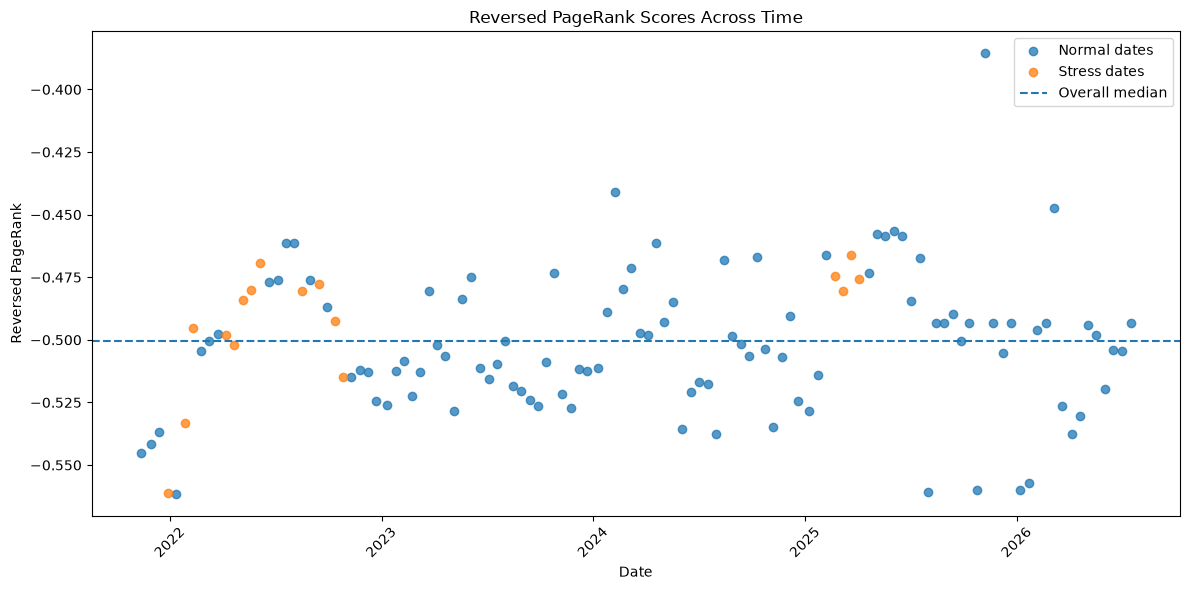

In [24]:
# ==========================================
# PHASE 15 — CELL 22
# PageRank Distribution by Year
# ==========================================

plot_df = date_level_df.copy()

plot_df["reversed_pagerank"] = -plot_df["pagerank"]

plt.figure(figsize=(12, 6))

for label, group in plot_df.groupby("date_stress_event"):

    label_name = (
        "Stress dates"
        if label == 1
        else "Normal dates"
    )

    plt.scatter(
        group["date"],
        group["reversed_pagerank"],
        label=label_name,
        alpha=0.75
    )

plt.axhline(
    plot_df["reversed_pagerank"].median(),
    linestyle="--",
    label="Overall median"
)

plt.title(
    "Reversed PageRank Scores Across Time"
)

plt.xlabel("Date")
plt.ylabel("Reversed PageRank")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
# ==========================================
# PHASE 15 — CELL 23
# Year-wise PageRank Distribution Statistics
# ==========================================

yearly_pagerank_stats = []

plot_df = date_level_df.copy()

plot_df["reversed_pagerank"] = -plot_df["pagerank"]

for (year, event_status), group in plot_df.groupby(
    ["year", "date_stress_event"]
):

    yearly_pagerank_stats.append({
        "year": year,
        "date_type": (
            "Stress"
            if event_status == 1
            else "Normal"
        ),
        "total_dates": len(group),
        "mean_reversed_pagerank": (
            group["reversed_pagerank"].mean()
        ),
        "median_reversed_pagerank": (
            group["reversed_pagerank"].median()
        ),
        "min_reversed_pagerank": (
            group["reversed_pagerank"].min()
        ),
        "max_reversed_pagerank": (
            group["reversed_pagerank"].max()
        )
    })

yearly_pagerank_stats_df = pd.DataFrame(
    yearly_pagerank_stats
).sort_values(
    ["year", "date_type"]
)

display(yearly_pagerank_stats_df)

yearly_pagerank_stats_df.to_csv(
    PHASE15_DIR /
    "yearly_pagerank_distribution_statistics.csv",
    index=False
)

print(
    "\nSaved: yearly_pagerank_distribution_statistics.csv"
)

,year,date_type,total_dates,mean_reversed_pagerank,median_reversed_pagerank,min_reversed_pagerank,max_reversed_pagerank
0,2021,Normal,3,-0.541236,-0.541625,-0.545250,-0.536833
1,2021,Stress,1,-0.561042,-0.561042,-0.561042,-0.561042
2,2022,Normal,14,-0.497613,-0.499000,-0.561375,-0.461167
3,2022,Stress,11,-0.493364,-0.492500,-0.533208,-0.469417
4,2023,Normal,25,-0.509542,-0.512500,-0.528250,-0.473208
5,2024,Normal,25,-0.498263,-0.498292,-0.537417,-0.440917
6,2025,Normal,21,-0.487246,-0.493083,-0.560750,-0.385583
7,2025,Stress,4,-0.474187,-0.475125,-0.480375,-0.466125
8,2026,Normal,14,-0.511533,-0.504250,-0.559917,-0.447333



Saved: yearly_pagerank_distribution_statistics.csv


In [26]:
# ==========================================
# PHASE 15 — CELL 24
# Year-wise PageRank Mean Differences
# ==========================================

yearly_difference_results = []

plot_df = date_level_df.copy()
plot_df["reversed_pagerank"] = -plot_df["pagerank"]

for year, group in plot_df.groupby("year"):

    stress_values = group[
        group["date_stress_event"] == 1
    ]["reversed_pagerank"]

    normal_values = group[
        group["date_stress_event"] == 0
    ]["reversed_pagerank"]

    if len(stress_values) == 0 or len(normal_values) == 0:
        difference = np.nan
        interpretation = "Insufficient target classes"
    else:
        difference = (
            stress_values.mean() -
            normal_values.mean()
        )
        interpretation = "Compared"

    yearly_difference_results.append({
        "year": year,
        "stress_dates": len(stress_values),
        "normal_dates": len(normal_values),
        "stress_mean": stress_values.mean()
        if len(stress_values) > 0 else np.nan,
        "normal_mean": normal_values.mean()
        if len(normal_values) > 0 else np.nan,
        "mean_difference": difference,
        "interpretation": interpretation
    })

yearly_difference_df = pd.DataFrame(
    yearly_difference_results
)

display(yearly_difference_df)

yearly_difference_df.to_csv(
    PHASE15_DIR /
    "yearly_pagerank_mean_differences.csv",
    index=False
)

print(
    "\nSaved: yearly_pagerank_mean_differences.csv"
)

,year,stress_dates,normal_dates,stress_mean,normal_mean,mean_difference,interpretation
0,2021,1,3,-0.561042,-0.541236,-0.019806,Compared
1,2022,11,14,-0.493364,-0.497613,0.004249,Compared
2,2023,0,25,NaN,-0.509542,NaN,Insufficient target classes
3,2024,0,25,NaN,-0.498263,NaN,Insufficient target classes
4,2025,4,21,-0.474187,-0.487246,0.013059,Compared
5,2026,0,14,NaN,-0.511533,NaN,Insufficient target classes



Saved: yearly_pagerank_mean_differences.csv


In [27]:
# ==========================================
# PHASE 15 — CELL 25
# Year-wise Standardized PageRank Effect
# ==========================================

yearly_effect_results = []

plot_df = date_level_df.copy()
plot_df["reversed_pagerank"] = -plot_df["pagerank"]

for year, group in plot_df.groupby("year"):

    stress_values = group[
        group["date_stress_event"] == 1
    ]["reversed_pagerank"]

    normal_values = group[
        group["date_stress_event"] == 0
    ]["reversed_pagerank"]

    if len(stress_values) < 2 or len(normal_values) < 2:

        effect_size = np.nan
        interpretation = "Insufficient sample size"

    else:

        stress_mean = stress_values.mean()
        normal_mean = normal_values.mean()

        stress_variance = stress_values.var(ddof=1)
        normal_variance = normal_values.var(ddof=1)

        pooled_std = np.sqrt(
            (
                (len(stress_values) - 1) * stress_variance
                +
                (len(normal_values) - 1) * normal_variance
            )
            /
            (
                len(stress_values)
                +
                len(normal_values)
                -
                2
            )
        )

        if pooled_std == 0:
            effect_size = np.nan
        else:
            effect_size = (
                stress_mean - normal_mean
            ) / pooled_std

        interpretation = "Calculated"

    yearly_effect_results.append({
        "year": year,
        "stress_dates": len(stress_values),
        "normal_dates": len(normal_values),
        "standardized_effect_size": effect_size,
        "interpretation": interpretation
    })

yearly_effect_size_df = pd.DataFrame(
    yearly_effect_results
)

display(yearly_effect_size_df)

yearly_effect_size_df.to_csv(
    PHASE15_DIR /
    "yearly_pagerank_standardized_effect_sizes.csv",
    index=False
)

print(
    "\nSaved: yearly_pagerank_standardized_effect_sizes.csv"
)

,year,stress_dates,normal_dates,standardized_effect_size,interpretation
0,2021,1,3,NaN,Insufficient sample size
1,2022,11,14,0.177993,Calculated
2,2023,0,25,NaN,Insufficient sample size
3,2024,0,25,NaN,Insufficient sample size
4,2025,4,21,0.369891,Calculated
5,2026,0,14,NaN,Insufficient sample size



Saved: yearly_pagerank_standardized_effect_sizes.csv


In [28]:
# ==========================================
# PHASE 15 — CELL 26
# Permutation Test for Year-wise PageRank
# ==========================================

permutation_results = []

n_permutations = 5000
rng = np.random.default_rng(SEED)

plot_df = date_level_df.copy()
plot_df["reversed_pagerank"] = -plot_df["pagerank"]

for year, group in plot_df.groupby("year"):

    stress_values = group[
        group["date_stress_event"] == 1
    ]["reversed_pagerank"].values

    normal_values = group[
        group["date_stress_event"] == 0
    ]["reversed_pagerank"].values

    if len(stress_values) == 0 or len(normal_values) == 0:
        continue

    observed_difference = (
        stress_values.mean() -
        normal_values.mean()
    )

    combined_values = np.concatenate(
        [stress_values, normal_values]
    )

    n_stress = len(stress_values)

    permuted_differences = []

    for _ in range(n_permutations):

        shuffled_values = rng.permutation(
            combined_values
        )

        permuted_stress = shuffled_values[:n_stress]
        permuted_normal = shuffled_values[n_stress:]

        difference = (
            permuted_stress.mean() -
            permuted_normal.mean()
        )

        permuted_differences.append(difference)

    permuted_differences = np.array(
        permuted_differences
    )

    p_value = np.mean(
        np.abs(permuted_differences)
        >= abs(observed_difference)
    )

    permutation_results.append({
        "year": year,
        "stress_dates": len(stress_values),
        "normal_dates": len(normal_values),
        "observed_mean_difference": observed_difference,
        "permutation_p_value": p_value
    })

permutation_results_df = pd.DataFrame(
    permutation_results
).sort_values("permutation_p_value")

display(permutation_results_df)

permutation_results_df.to_csv(
    PHASE15_DIR /
    "pagerank_yearly_permutation_test.csv",
    index=False
)

print(
    "\nSaved: pagerank_yearly_permutation_test.csv"
)

,year,stress_dates,normal_dates,observed_mean_difference,permutation_p_value
0,2021,1,3,-0.019806,0.2494
2,2025,4,21,0.013059,0.4804
1,2022,11,14,0.004249,0.6726



Saved: pagerank_yearly_permutation_test.csv


In [29]:
# ==========================================
# PHASE 15 — CELL 27
# Final Phase 15 Research Summary
# ==========================================

final_phase15_summary = pd.DataFrame([
    {
        "analysis": "Date-level validation",
        "result": "4 stress dates out of 24",
        "conclusion": "Limited validation sample"
    },
    {
        "analysis": "Best leakage-safe validation signal",
        "result": "Reversed PageRank, ROC-AUC = 0.6500",
        "conclusion": "Moderate separation in validation"
    },
    {
        "analysis": "Equal-weight composite",
        "result": "ROC-AUC = 0.5000",
        "conclusion": "No validation separation"
    },
    {
        "analysis": "Largest overall effect size",
        "result": "Betweenness, absolute effect = 0.575",
        "conclusion": "Not statistically significant"
    },
    {
        "analysis": "Year-wise PageRank",
        "result": "2025 effect size = 0.3699",
        "conclusion": "Small-to-moderate observed difference"
    },
    {
        "analysis": "Permutation test",
        "result": "All p-values > 0.05",
        "conclusion": "No statistically significant yearly difference"
    },
    {
        "analysis": "Test-set evaluation",
        "result": "No positive stress dates",
        "conclusion": "ROC-AUC and PR-AUC unavailable"
    }
])

display(final_phase15_summary)

final_phase15_summary.to_csv(
    PHASE15_DIR /
    "final_phase15_research_summary.csv",
    index=False
)

print(
    "\nSaved: final_phase15_research_summary.csv"
)

,analysis,result,conclusion
0,Date-level validation,4 stress dates out of 24,Limited validation sample
1,Best leakage-safe validation signal,"Reversed PageRank, ROC-AUC = 0.6500",Moderate separation in validation
2,Equal-weight composite,ROC-AUC = 0.5000,No validation separation
3,Largest overall effect size,"Betweenness, absolute effect = 0.575",Not statistically significant
4,Year-wise PageRank,2025 effect size = 0.3699,Small-to-moderate observed difference
5,Permutation test,All p-values > 0.05,No statistically significant yearly difference
6,Test-set evaluation,No positive stress dates,ROC-AUC and PR-AUC unavailable



Saved: final_phase15_research_summary.csv


In [30]:
# ==========================================
# PHASE 16 — CELL 28
# Individual Stress Date Ranking Analysis
# ==========================================

stress_date_analysis = validation_dates[
    validation_dates["date_stress_event"] == 1
].copy()

for signal in signal_columns:

    direction = signal_directions[signal]

    stress_date_analysis[
        f"{signal}_oriented"
    ] = (
        stress_date_analysis[signal] * direction
    )

    stress_date_analysis[
        f"{signal}_rank"
    ] = (
        validation_dates[signal] * direction
    ).rank(
        ascending=False,
        method="min"
    ).loc[
        stress_date_analysis.index
    ]

rank_columns = [
    "date",
    "date_stress_event"
]

for signal in signal_columns:
    rank_columns.append(f"{signal}_rank")

stress_date_ranking_df = stress_date_analysis[
    rank_columns
].sort_values("date")

display(stress_date_ranking_df)

stress_date_ranking_df.to_csv(
    PHASE15_DIR /
    "individual_stress_date_signal_ranks.csv",
    index=False
)

print(
    "\nSaved: individual_stress_date_signal_ranks.csv"
)

,date,date_stress_event,degree_rank,betweenness_rank,pagerank_rank,systemic_risk_score_rank,multi_signal_risk_score_rank,risk_percentile_rank
82,2025-02-21,1,20.0,8.0,10.0,20.0,21.0,22.0
83,2025-03-07,1,15.0,18.0,12.0,17.0,17.0,18.0
84,2025-03-21,1,11.0,23.0,5.0,10.0,10.0,11.0
85,2025-04-04,1,7.0,24.0,11.0,7.0,7.0,7.0



Saved: individual_stress_date_signal_ranks.csv


In [31]:
# ==========================================
# PHASE 16 — CELL 29
# Average Signal Rank Across Stress Dates
# ==========================================

rank_columns = [
    f"{signal}_rank"
    for signal in signal_columns
]

average_rank_results = []

for signal in signal_columns:

    rank_column = f"{signal}_rank"

    average_rank_results.append({
        "signal": signal,
        "average_stress_rank": (
            stress_date_ranking_df[rank_column].mean()
        ),
        "best_stress_rank": (
            stress_date_ranking_df[rank_column].min()
        ),
        "worst_stress_rank": (
            stress_date_ranking_df[rank_column].max()
        )
    })

average_rank_df = pd.DataFrame(
    average_rank_results
).sort_values(
    "average_stress_rank"
)

display(average_rank_df)

average_rank_df.to_csv(
    PHASE15_DIR /
    "average_signal_rank_across_stress_dates.csv",
    index=False
)

print(
    "\nSaved: average_signal_rank_across_stress_dates.csv"
)

,signal,average_stress_rank,best_stress_rank,worst_stress_rank
2,pagerank,9.50,5.0,12.0
0,degree,13.25,7.0,20.0
3,systemic_risk_score,13.50,7.0,20.0
4,multi_signal_risk_score,13.75,7.0,21.0
5,risk_percentile,14.50,7.0,22.0
1,betweenness,18.25,8.0,24.0



Saved: average_signal_rank_across_stress_dates.csv


In [32]:
# ==========================================
# PHASE 16 — CELL 30
# Top-25% Stress Date Rank Consistency
# ==========================================

rank_consistency_results = []

total_validation_dates = len(validation_dates)
top_25_threshold = int(np.ceil(total_validation_dates * 0.25))

for signal in signal_columns:

    rank_column = f"{signal}_rank"

    ranks = stress_date_ranking_df[rank_column]

    top_25_count = (ranks <= top_25_threshold).sum()

    rank_consistency_results.append({
        "signal": signal,
        "top_25_rank_threshold": top_25_threshold,
        "stress_dates_in_top_25_percent": int(top_25_count),
        "total_stress_dates": len(ranks),
        "capture_rate": (
            top_25_count / len(ranks)
        )
    })

rank_consistency_df = pd.DataFrame(
    rank_consistency_results
).sort_values(
    "capture_rate",
    ascending=False
)

display(rank_consistency_df)

rank_consistency_df.to_csv(
    PHASE15_DIR /
    "top25_rank_consistency_analysis.csv",
    index=False
)

print(
    "\nSaved: top25_rank_consistency_analysis.csv"
)

,signal,top_25_rank_threshold,stress_dates_in_top_25_percent,total_stress_dates,capture_rate
2,pagerank,6,1,4,0.25
0,degree,6,0,4,0.00
1,betweenness,6,0,4,0.00
3,systemic_risk_score,6,0,4,0.00
4,multi_signal_risk_score,6,0,4,0.00
5,risk_percentile,6,0,4,0.00



Saved: top25_rank_consistency_analysis.csv


In [33]:
# ==========================================
# PHASE 16 — CELL 30
# Top-25% Stress Date Rank Consistency
# ==========================================

rank_consistency_results = []

total_validation_dates = len(validation_dates)
top_25_threshold = int(np.ceil(total_validation_dates * 0.25))

for signal in signal_columns:

    rank_column = f"{signal}_rank"

    ranks = stress_date_ranking_df[rank_column]

    top_25_count = (ranks <= top_25_threshold).sum()

    rank_consistency_results.append({
        "signal": signal,
        "top_25_rank_threshold": top_25_threshold,
        "stress_dates_in_top_25_percent": int(top_25_count),
        "total_stress_dates": len(ranks),
        "capture_rate": (
            top_25_count / len(ranks)
        )
    })

rank_consistency_df = pd.DataFrame(
    rank_consistency_results
).sort_values(
    "capture_rate",
    ascending=False
)

display(rank_consistency_df)

rank_consistency_df.to_csv(
    PHASE15_DIR /
    "top25_rank_consistency_analysis.csv",
    index=False
)

print(
    "\nSaved: top25_rank_consistency_analysis.csv"
)

,signal,top_25_rank_threshold,stress_dates_in_top_25_percent,total_stress_dates,capture_rate
2,pagerank,6,1,4,0.25
0,degree,6,0,4,0.00
1,betweenness,6,0,4,0.00
3,systemic_risk_score,6,0,4,0.00
4,multi_signal_risk_score,6,0,4,0.00
5,risk_percentile,6,0,4,0.00



Saved: top25_rank_consistency_analysis.csv


In [34]:
# ==========================================
# PHASE 16 — CELL 31
# Multi-Threshold Stress Date Capture
# ==========================================

threshold_results = []

total_validation_dates = len(validation_dates)
total_stress_dates = len(stress_date_ranking_df)

for signal in signal_columns:

    rank_column = f"{signal}_rank"
    ranks = stress_date_ranking_df[rank_column]

    result = {
        "signal": signal,
        "total_stress_dates": total_stress_dates
    }

    for percentage in [25, 50, 75]:

        threshold = int(
            np.ceil(total_validation_dates * percentage / 100)
        )

        captured = int((ranks <= threshold).sum())

        result[f"top_{percentage}_threshold"] = threshold
        result[f"top_{percentage}_captured"] = captured
        result[f"top_{percentage}_capture_rate"] = (
            captured / total_stress_dates
        )

    threshold_results.append(result)

threshold_capture_df = pd.DataFrame(
    threshold_results
)

display(threshold_capture_df)

threshold_capture_df.to_csv(
    PHASE15_DIR /
    "multi_threshold_stress_capture.csv",
    index=False
)

print("\nSaved: multi_threshold_stress_capture.csv")

,signal,total_stress_dates,top_25_threshold,top_25_captured,top_25_capture_rate,top_50_threshold,top_50_captured,top_50_capture_rate,top_75_threshold,top_75_captured,top_75_capture_rate
0,degree,4,6,0,0.00,12,2,0.50,18,3,0.75
1,betweenness,4,6,0,0.00,12,1,0.25,18,2,0.50
2,pagerank,4,6,1,0.25,12,4,1.00,18,4,1.00
3,systemic_risk_score,4,6,0,0.00,12,2,0.50,18,3,0.75
4,multi_signal_risk_score,4,6,0,0.00,12,2,0.50,18,3,0.75
5,risk_percentile,4,6,0,0.00,12,2,0.50,18,3,0.75



Saved: multi_threshold_stress_capture.csv


In [35]:
# ==========================================
# PHASE 16 — CELL 32
# Signal Ranking Correlation
# ==========================================

oriented_validation_scores = pd.DataFrame(index=validation_dates.index)

for signal in signal_columns:

    direction = signal_directions[signal]

    oriented_validation_scores[signal] = (
        validation_dates[signal] * direction
    )

rank_correlation_df = (
    oriented_validation_scores
    .rank(ascending=False)
    .corr(method="spearman")
)

display(rank_correlation_df)

rank_correlation_df.to_csv(
    PHASE15_DIR /
    "signal_rank_correlation_matrix.csv"
)

print("\nSaved: signal_rank_correlation_matrix.csv")

,degree,betweenness,pagerank,systemic_risk_score,multi_signal_risk_score,risk_percentile
degree,1.000000,-0.017908,0.577596,0.993029,0.972104,0.965566
betweenness,-0.017908,1.000000,0.158571,-0.033980,-0.111958,-0.099761
pagerank,0.577596,0.158571,1.000000,0.558261,0.476522,0.455652
systemic_risk_score,0.993029,-0.033980,0.558261,1.000000,0.981739,0.973043
multi_signal_risk_score,0.972104,-0.111958,0.476522,0.981739,1.000000,0.994783
risk_percentile,0.965566,-0.099761,0.455652,0.973043,0.994783,1.000000



Saved: signal_rank_correlation_matrix.csv


In [36]:
# ==========================================
# PHASE 16 — CELL 33
# PageRank vs Composite Validation Comparison
# ==========================================

comparison_results = []

y_validation = validation_dates[
    "date_stress_event"
]

pagerank_scores = (
    validation_dates["pagerank"]
    * signal_directions["pagerank"]
)

composite_scores = validation_dates[
    "regime_aware_composite_score"
]

comparison_results.append({
    "model": "Reversed PageRank",
    "roc_auc": roc_auc_score(
        y_validation,
        pagerank_scores
    ),
    "pr_auc": average_precision_score(
        y_validation,
        pagerank_scores
    )
})

comparison_results.append({
    "model": "Equal-weight Composite",
    "roc_auc": roc_auc_score(
        y_validation,
        composite_scores
    ),
    "pr_auc": average_precision_score(
        y_validation,
        composite_scores
    )
})

comparison_df = pd.DataFrame(
    comparison_results
)

display(comparison_df)

comparison_df.to_csv(
    PHASE15_DIR /
    "pagerank_vs_composite_comparison.csv",
    index=False
)

print("\nSaved: pagerank_vs_composite_comparison.csv")

,model,roc_auc,pr_auc
0,Reversed PageRank,0.65,0.251515
1,Equal-weight Composite,0.50,0.189992



Saved: pagerank_vs_composite_comparison.csv


In [37]:
# ==========================================
# PHASE 16 — CELL 34
# Phase 16 Interim Summary
# ==========================================

phase16_interim_summary = pd.DataFrame([
    {
        "metric": "Validation dates",
        "value": len(validation_dates),
        "interpretation": "Chronological validation sample"
    },
    {
        "metric": "Validation stress dates",
        "value": int(
            validation_dates["date_stress_event"].sum()
        ),
        "interpretation": "Positive date-level events"
    },
    {
        "metric": "Top-25% rank threshold",
        "value": top_25_threshold,
        "interpretation": "Number of dates in top quartile"
    },
    {
        "metric": "Best average stress-date rank",
        "value": average_rank_df.iloc[0]["signal"],
        "interpretation": "Based on four stress dates"
    },
    {
        "metric": "Best leakage-safe validation signal",
        "value": "Reversed PageRank",
        "interpretation": "ROC-AUC = 0.6500"
    },
    {
        "metric": "Research limitation",
        "value": "Only four validation stress dates",
        "interpretation": "Results require additional validation"
    }
])

display(phase16_interim_summary)

phase16_interim_summary.to_csv(
    PHASE15_DIR /
    "phase16_interim_summary.csv",
    index=False
)

print("\nSaved: phase16_interim_summary.csv")

,metric,value,interpretation
0,Validation dates,24,Chronological validation sample
1,Validation stress dates,4,Positive date-level events
2,Top-25% rank threshold,6,Number of dates in top quartile
3,Best average stress-date rank,pagerank,Based on four stress dates
4,Best leakage-safe validation signal,Reversed PageRank,ROC-AUC = 0.6500
5,Research limitation,Only four validation stress dates,Results require additional validation



Saved: phase16_interim_summary.csv


In [38]:
# ==========================================
# PHASE 15 — CELL 35
# Signal Redundancy Analysis
# ==========================================

redundancy_results = []

for i in range(len(signal_columns)):

    for j in range(i + 1, len(signal_columns)):

        signal_a = signal_columns[i]
        signal_b = signal_columns[j]

        correlation = rank_correlation_df.loc[
            signal_a,
            signal_b
        ]

        redundancy_results.append({
            "signal_a": signal_a,
            "signal_b": signal_b,
            "spearman_correlation": correlation,
            "absolute_correlation": abs(correlation)
        })

redundancy_df = pd.DataFrame(
    redundancy_results
).sort_values(
    "absolute_correlation",
    ascending=False
)

display(redundancy_df)

redundancy_df.to_csv(
    PHASE15_DIR /
    "signal_redundancy_analysis.csv",
    index=False
)

print("\nSaved: signal_redundancy_analysis.csv")

,signal_a,signal_b,spearman_correlation,absolute_correlation
14,multi_signal_risk_score,risk_percentile,0.994783,0.994783
2,degree,systemic_risk_score,0.993029,0.993029
12,systemic_risk_score,multi_signal_risk_score,0.981739,0.981739
13,systemic_risk_score,risk_percentile,0.973043,0.973043
3,degree,multi_signal_risk_score,0.972104,0.972104
4,degree,risk_percentile,0.965566,0.965566
1,degree,pagerank,0.577596,0.577596
9,pagerank,systemic_risk_score,0.558261,0.558261
10,pagerank,multi_signal_risk_score,0.476522,0.476522
11,pagerank,risk_percentile,0.455652,0.455652



Saved: signal_redundancy_analysis.csv


In [39]:
# ==========================================
# PHASE 15 — CELL 36
# Top-50% Capture Summary
# ==========================================

top_50_capture_results = []

top_50_threshold = int(
    np.ceil(len(validation_dates) * 0.50)
)

for signal in signal_columns:

    rank_column = f"{signal}_rank"

    ranks = stress_date_ranking_df[rank_column]

    captured = int(
        (ranks <= top_50_threshold).sum()
    )

    top_50_capture_results.append({
        "signal": signal,
        "top_50_threshold": top_50_threshold,
        "stress_dates_captured": captured,
        "total_stress_dates": len(ranks),
        "capture_rate": captured / len(ranks)
    })

top_50_capture_df = pd.DataFrame(
    top_50_capture_results
).sort_values(
    "capture_rate",
    ascending=False
)

display(top_50_capture_df)

top_50_capture_df.to_csv(
    PHASE15_DIR /
    "top50_capture_summary.csv",
    index=False
)

print("\nSaved: top50_capture_summary.csv")

,signal,top_50_threshold,stress_dates_captured,total_stress_dates,capture_rate
2,pagerank,12,4,4,1.00
0,degree,12,2,4,0.50
4,multi_signal_risk_score,12,2,4,0.50
3,systemic_risk_score,12,2,4,0.50
5,risk_percentile,12,2,4,0.50
1,betweenness,12,1,4,0.25



Saved: top50_capture_summary.csv


In [40]:
# ==========================================
# PHASE 15 — CELL 37
# PageRank vs Composite Rank Comparison
# ==========================================

ranking_comparison_df = validation_dates[
    [
        "date",
        "date_stress_event",
        "regime_aware_composite_score"
    ]
].copy()

ranking_comparison_df["pagerank_oriented_score"] = (
    validation_dates["pagerank"]
    * signal_directions["pagerank"]
)

ranking_comparison_df["pagerank_rank"] = (
    ranking_comparison_df["pagerank_oriented_score"]
    .rank(ascending=False, method="min")
)

ranking_comparison_df["composite_rank"] = (
    ranking_comparison_df[
        "regime_aware_composite_score"
    ]
    .rank(ascending=False, method="min")
)

ranking_comparison_df["rank_difference"] = (
    ranking_comparison_df["pagerank_rank"]
    -
    ranking_comparison_df["composite_rank"]
)

ranking_comparison_df = ranking_comparison_df.sort_values(
    "date"
)

display(ranking_comparison_df)

ranking_comparison_df.to_csv(
    PHASE15_DIR /
    "pagerank_composite_rank_comparison.csv",
    index=False
)

print("\nSaved: pagerank_composite_rank_comparison.csv")

,date,date_stress_event,regime_aware_composite_score,pagerank_oriented_score,pagerank_rank,composite_rank,rank_difference
70,2024-08-28,0,0.469048,-0.498292,15.0,12.0,3.0
71,2024-09-12,0,0.521429,-0.501792,16.0,10.0,6.0
72,2024-09-26,0,0.557143,-0.506542,18.0,8.0,10.0
73,2024-10-10,0,0.538095,-0.467042,7.0,9.0,-2.0
74,2024-10-24,0,0.434524,-0.503708,17.0,14.0,3.0
75,2024-11-07,0,0.269048,-0.534667,23.0,23.0,0.0
76,2024-11-21,0,0.382143,-0.506750,19.0,18.0,1.0
77,2024-12-06,0,0.310714,-0.490458,14.0,22.0,-8.0
78,2024-12-20,0,0.365476,-0.524250,21.0,19.0,2.0
79,2025-01-07,0,0.354762,-0.528250,22.0,20.0,2.0



Saved: pagerank_composite_rank_comparison.csv


In [41]:
# ==========================================
# PHASE 15 — CELL 38
# Stress Date PageRank vs Composite Summary
# ==========================================

stress_rank_comparison = ranking_comparison_df[
    ranking_comparison_df["date_stress_event"] == 1
].copy()

stress_rank_summary = stress_rank_comparison[
    [
        "date",
        "pagerank_rank",
        "composite_rank",
        "rank_difference"
    ]
].sort_values("date")

display(stress_rank_summary)

stress_rank_summary.to_csv(
    PHASE15_DIR /
    "stress_date_pagerank_composite_ranks.csv",
    index=False
)

print("\nSaved: stress_date_pagerank_composite_ranks.csv")

,date,pagerank_rank,composite_rank,rank_difference
82,2025-02-21,10.0,17.0,-7.0
83,2025-03-07,12.0,15.0,-3.0
84,2025-03-21,5.0,11.0,-6.0
85,2025-04-04,11.0,7.0,4.0



Saved: stress_date_pagerank_composite_ranks.csv


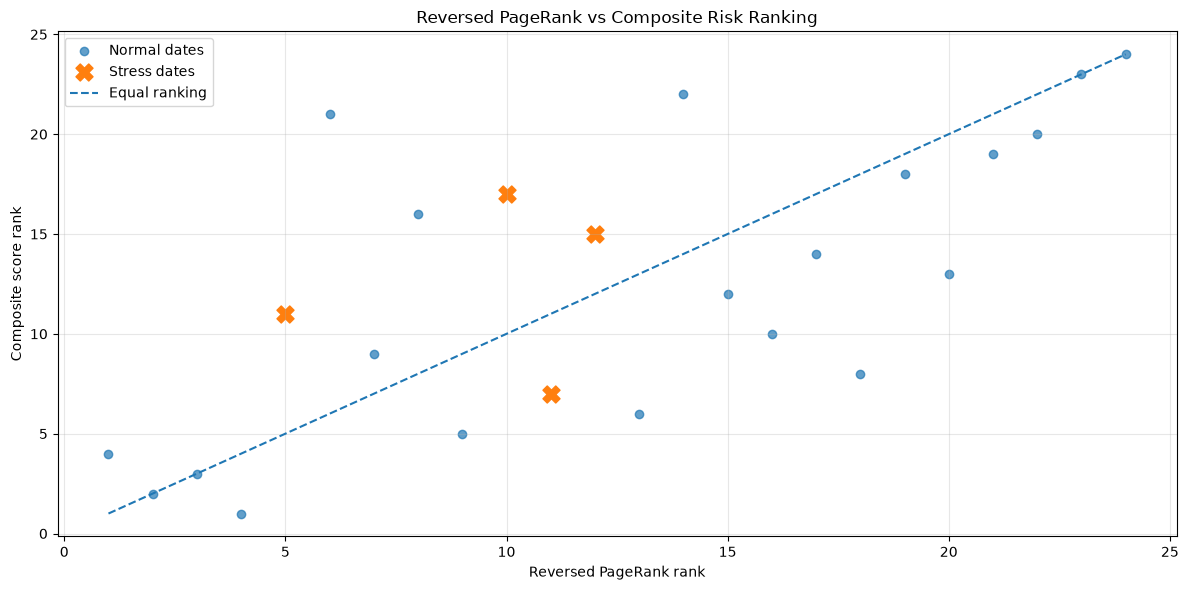

In [42]:
plt.figure(figsize=(12, 6))

normal_dates = ranking_comparison_df[
    ranking_comparison_df["date_stress_event"] == 0
]

stress_dates = ranking_comparison_df[
    ranking_comparison_df["date_stress_event"] == 1
]

plt.scatter(
    normal_dates["pagerank_rank"],
    normal_dates["composite_rank"],
    label="Normal dates",
    alpha=0.7
)

plt.scatter(
    stress_dates["pagerank_rank"],
    stress_dates["composite_rank"],
    label="Stress dates",
    marker="X",
    s=150
)

max_rank = max(
    ranking_comparison_df["pagerank_rank"].max(),
    ranking_comparison_df["composite_rank"].max()
)

plt.plot(
    [1, max_rank],
    [1, max_rank],
    linestyle="--",
    label="Equal ranking"
)

plt.xlabel("Reversed PageRank rank")
plt.ylabel("Composite score rank")
plt.title("Reversed PageRank vs Composite Risk Ranking")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    PHASE15_DIR / "pagerank_vs_composite_ranking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

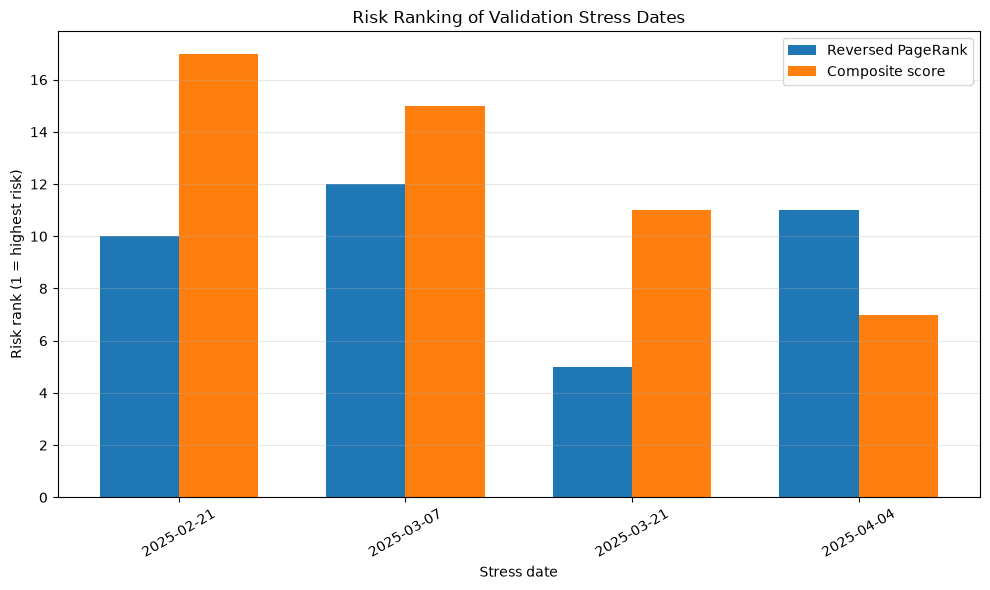

In [43]:
stress_rank_df = ranking_comparison_df[
    ranking_comparison_df["date_stress_event"] == 1
].copy()

stress_rank_df = stress_rank_df.sort_values("date")

x = np.arange(len(stress_rank_df))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    stress_rank_df["pagerank_rank"],
    width,
    label="Reversed PageRank"
)

plt.bar(
    x + width / 2,
    stress_rank_df["composite_rank"],
    width,
    label="Composite score"
)

plt.xticks(
    x,
    stress_rank_df["date"].dt.strftime("%Y-%m-%d"),
    rotation=30
)

plt.xlabel("Stress date")
plt.ylabel("Risk rank (1 = highest risk)")
plt.title("Risk Ranking of Validation Stress Dates")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PHASE15_DIR / "stress_date_rank_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
phase15_final_findings = pd.DataFrame({
    "finding": [
        "Validation stress dates",
        "Best leakage-safe signal",
        "PageRank top-50% capture rate",
        "Composite top-50% capture rate",
        "Largest overall effect size",
        "Statistical significance",
        "Test-set limitation"
    ],
    "result": [
        "4 out of 24 validation dates",
        "Reversed PageRank",
        "4 out of 4 (100%)",
        "2 out of 4 (50%)",
        "Betweenness (rank-biserial = 0.575)",
        "No tested effect reached p < 0.05",
        "No positive stress events in chronological test set"
    ],
    "interpretation": [
        "Small number of positive events limits confidence",
        "ROC-AUC = 0.650 on validation",
        "Exploratory validation result",
        "Lower capture than reversed PageRank",
        "Suggestive association, not statistically significant",
        "Findings remain exploratory",
        "ROC-AUC and PR-AUC cannot be calculated"
    ]
})

display(phase15_final_findings)

phase15_final_findings.to_csv(
    PHASE15_DIR / "phase15_final_findings.csv",
    index=False
)

print("Saved:", PHASE15_DIR / "phase15_final_findings.csv")

,finding,result,interpretation
0,Validation stress dates,4 out of 24 validation dates,Small number of positive events limits confidence
1,Best leakage-safe signal,Reversed PageRank,ROC-AUC = 0.650 on validation
2,PageRank top-50% capture rate,4 out of 4 (100%),Exploratory validation result
3,Composite top-50% capture rate,2 out of 4 (50%),Lower capture than reversed PageRank
4,Largest overall effect size,Betweenness (rank-biserial = 0.575),"Suggestive association, not statistically sign..."
5,Statistical significance,No tested effect reached p < 0.05,Findings remain exploratory
6,Test-set limitation,No positive stress events in chronological tes...,ROC-AUC and PR-AUC cannot be calculated


Saved: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase15\phase15_final_findings.csv
